In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

# Your Google Drive dataset folder
DATASET_DIR = Path("/content/drive/MyDrive/esp32_dataset")

ACTIVATE_DIR = DATASET_DIR / "Activate"
NO_DIR = DATASET_DIR / "No"
SILENCE_DIR = DATASET_DIR / "Silence"

print("Activate folder:", ACTIVATE_DIR)
print("No folder:", NO_DIR)
print("Silence:", SILENCE_DIR)


Activate folder: /content/drive/MyDrive/esp32_dataset/Activate
No folder: /content/drive/MyDrive/esp32_dataset/No
Silence: /content/drive/MyDrive/esp32_dataset/Silence


**Data Augmentations**

In [ ]:
import tensorflow as tf
from tensorflow.lite.experimental.microfrontend.python.ops import audio_microfrontend_op as frontend_op
import numpy as np
import time
from scipy.io import wavfile
import random
import sys
import io
import os
import pathlib
import glob
from datetime import datetime as dt
from numpy import log as ln
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
import IPython
import IPython.display as ipd
import tensorflow as tf
%matplotlib inline
from queue import Queue
from threading import Thread
import math
import time
import librosa

In [ ]:
!apt-get -qq update
!apt-get -y install portaudio19-dev
!pip install -q PyAudio

import pyaudio
print(pyaudio.__version__)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
portaudio19-dev is already the newest version (19.6.0-1.1).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
0.2.14


In [ ]:
i16min            = -32768
i16max            = 32767
fsamp             = 16000
wave_length_ms    = 1000
wave_length_samps = 16000
window_size_ms    = 60
window_step_ms    = 40
num_filters       = 32
use_microfrontend = True
keyword        = 'activate'#####Insert your keyword
spectrogram_shape = (64, 24, 32, 1)

chunk_duration = 0.25 # Each read length in seconds from mic.
fs = 16000 # sampling rate for mic
sample_rate = 16000 # sampling rate for mic
chunk_samples = int(fs * chunk_duration) # Each read length in number of samples.

# Each model input data duration in seconds, need to be an integer numbers of chunk_duration
feed_duration = 1.0
feed_samples = int(fs * feed_duration)

assert feed_duration/chunk_duration == int(feed_duration/chunk_duration)

In [ ]:
parent_dir = "/content/drive/MyDrive/esp32_dataset/Activate" #gets current directory
parent_dir
folder_pre = "Augmented_"
folder = folder_pre + keyword
dir = os.path.join(parent_dir,folder)
noise_dir=os.path.join(parent_dir,"noise")
#os.mkdir(dir) #creating folder
#os.mkdir(noise_dir) #creating folder
keyword_directory=dir + '\\'
print("Directory '% s' created" % folder)
print("Directory 'noise' created")

Directory 'Augmented_activate' created
Directory 'noise' created


**Get Custom Data**

In [ ]:
!pip install ffmpeg-python

from IPython.display import Javascript, display, Audio
from google.colab import output
from base64 import b64decode
import scipy.io.wavfile as wavfile
import numpy as np
import io
import ffmpeg
import os

<IPython.core.display.Javascript object>

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

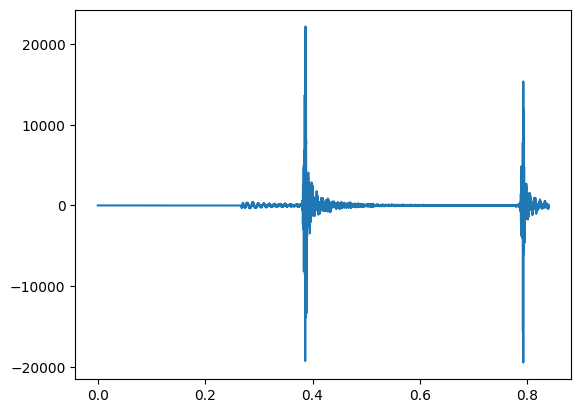

In [ ]:


RECORD = """
async function record(sec) {
  const stream = await navigator.mediaDevices.getUserMedia({audio: true});
  const recorder = new MediaRecorder(stream);
  const chunks = [];

  recorder.ondataavailable = e => chunks.push(e.data);
  recorder.start();

  await new Promise(resolve => setTimeout(resolve, sec * 1000));
  recorder.stop();

  await new Promise(resolve => recorder.onstop = resolve);

  const blob = new Blob(chunks, { type: 'audio/webm' });
  const reader = new FileReader();
  reader.readAsDataURL(blob);
  await new Promise(resolve => reader.onloadend = resolve);

  stream.getTracks().forEach(track => track.stop());
  return reader.result;
}
"""

display(Javascript(RECORD))

audio_data = output.eval_js("record(1)")   # record 1 second
with open("recorded_audio.webm", "wb") as f:
    f.write(b64decode(audio_data.split(",")[1]))

# convert webm to wav at 16 kHz mono
!ffmpeg -y -i recorded_audio.webm -ar 16000 -ac 1 recorded_audio.wav

sample_rate, data = wavfile.read("recorded_audio.wav")

import matplotlib.pyplot as plt
plt.plot(np.arange(len(data)) / sample_rate, data)
plt.show()

Audio(data, rate=sample_rate)

In [ ]:
date_str = dt.now().strftime("%H%M%S").lower()
current_name = f"{keyword_directory}{keyword}_{date_str}.wav"
write(current_name, sample_rate, data)
print("Audio sample saved")

Audio sample saved


In [ ]:
# #saving the wave file to training_data
date_str = dt.now().strftime("%H%M%S").lower()
current_name = f"{parent_dir}/noise/noise_{date_str}.wav"
write(current_name, sample_rate, data)
print("Audio sample saved as noise")

Audio sample saved as noise


**Audio Augmentation - Noise**

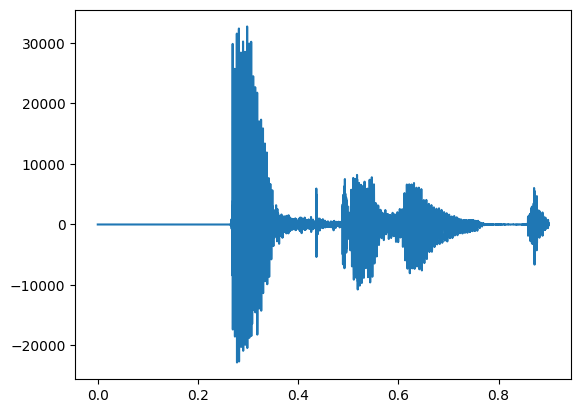

In [ ]:
#Selecting augmentation folder & files
data_dir = dir
filenames = tf.io.gfile.glob(str(data_dir) + '/*.wav')
#Testing if audio data imported correctly
test_wav=filenames[0]
fs, test_wav = wavfile.read(test_wav)
plt.plot(np.arange(len(test_wav))/fs, test_wav)
plt.show()
ipd.Audio(test_wav, rate=fs)


In [ ]:
#Loading noise samples
noise_dir = parent_dir+'/noise'
noise_dir
noise_samples = tf.io.gfile.glob(str(noise_dir) + '/*.wav')
print("Noise Samples:", len(noise_samples))

Noise Samples: 2


**Adding Synthetic Data to the Activate Dataset - US,UK and Indian accent**

**Set Augment Count**

In [ ]:
noise_count=4
print("This will expand the current", len(filenames), "files by creating an addtional",len(filenames)*len(noise_samples)*noise_count, "noise augmented files, to give a total of",len(filenames)*len(noise_samples)*(noise_count)+len(filenames),"files")

This will expand the current 6 files by creating an addtional 48 noise augmented files, to give a total of 54 files


**Creating Noise Augmentations**

In [ ]:
noise_dict={}
for index in range(len(filenames)):
    test_wav=filenames[index]
    fs, test_wav = wavfile.read(test_wav)
    if (len(test_wav) < fs):
        padding=fs-len(test_wav)
        extra_padding=np.zeros(padding).astype(np.int16) #array of empty audio to pad with
        test_wav=np.concatenate((test_wav,extra_padding),axis=0).astype(np.int16)
    elif (len(test_wav) > fs):
        test_wav = test_wav[:fs].astype(np.int16)
    noise_dict[0]=test_wav.astype(np.int16)
    for i in range(len(noise_samples)):
        noise=noise_samples[i]
        fs, noise = wavfile.read(noise)
        # Ensure noise has the same length as test_wav (which is fs=16000 after padding/truncation)
        if len(noise) < fs:
            noise_padding = fs - len(noise)
            extra_noise_padding = np.zeros(noise_padding).astype(np.int16)
            noise = np.concatenate((noise, extra_noise_padding), axis=0).astype(np.int16)
        elif len(noise) > fs:
            noise = noise[:fs].astype(np.int16) # Truncate if longer

        for j in range(noise_count):
            noise_multiplier=round(max(test_wav)*(j/2000))
            noise_lvl=noise*noise_multiplier
            test_wave_with_noise=np.add(test_wav,noise_lvl)
            current_name = str(keyword_directory) + str(keyword)+f"_Sample{index}_Noise{i}_Multiplier{j}.wav"
            write(current_name, fs, test_wave_with_noise)
            noise_dict[j+1]=test_wave_with_noise.astype(np.int16)
            noise_dict[j+5]=noise_lvl.astype(np.int16)

**Plotting Noise Augmentations**

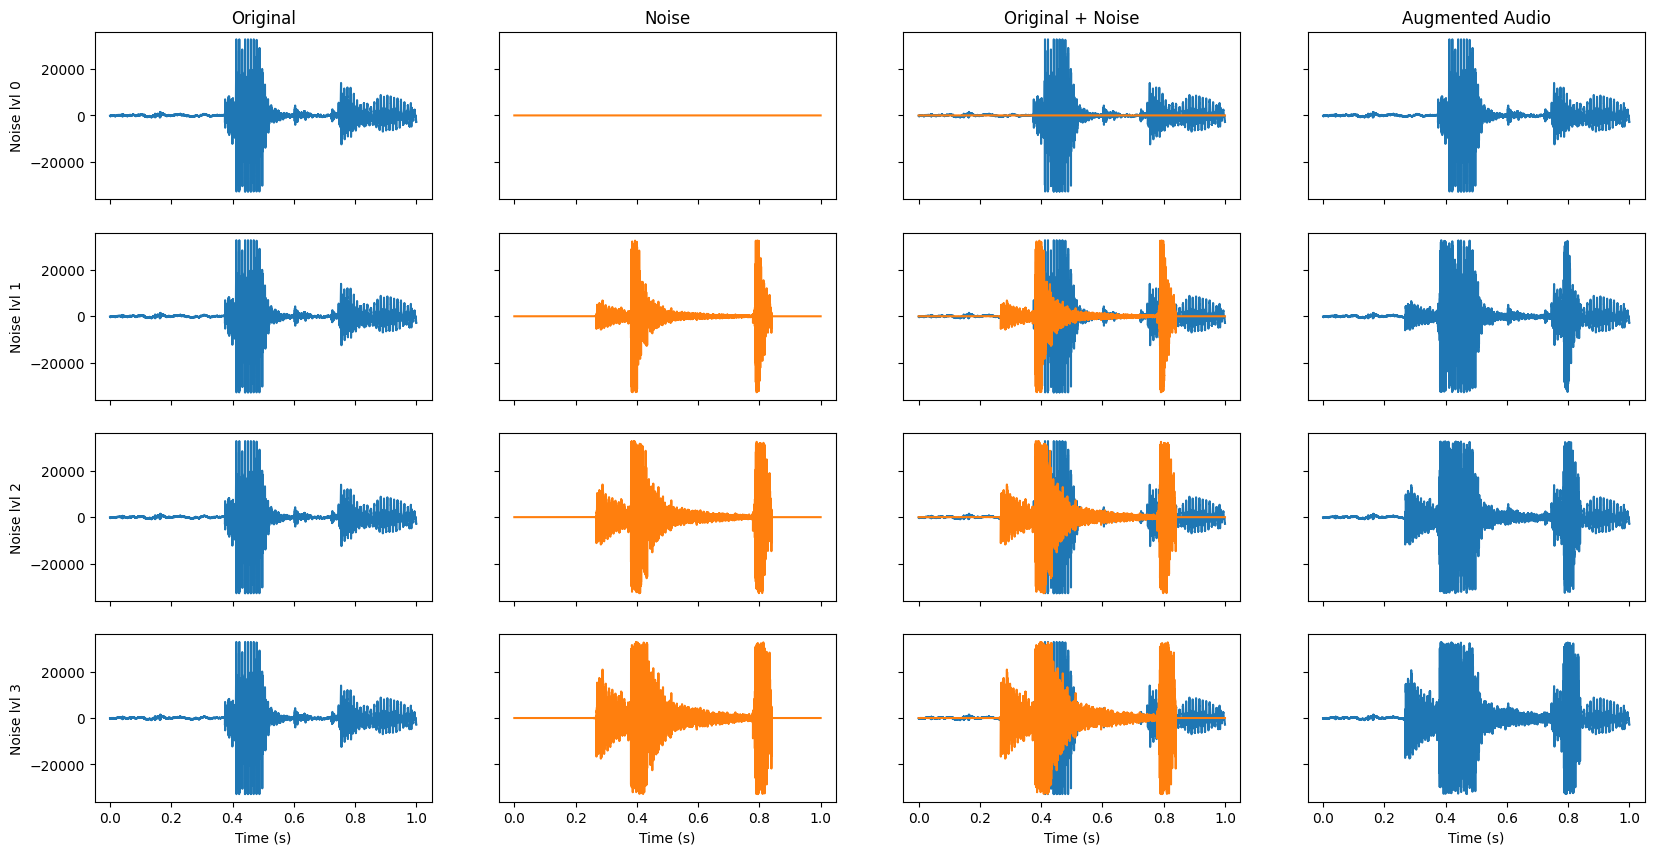

In [ ]:
#Only plots up to noise lvl 3
fig, axs = plt.subplots(4, 4,figsize=(20,10), sharex=True,sharey=True)
axs[0,0].plot(np.arange(1*fs)/fs, noise_dict[0])
axs[0,1].plot(np.arange(1*fs)/fs, noise_dict[5], 'tab:orange')
axs[0,2].plot(np.arange(1*fs)/fs, noise_dict[0])
axs[0,2].plot(np.arange(1*fs)/fs, noise_dict[5])
axs[0,3].plot(np.arange(1*fs)/fs, noise_dict[1])

axs[0, 0].set_title("Original")
axs[0, 1].set_title("Noise")
axs[0, 2].set_title("Original + Noise")
axs[0, 3].set_title("Augmented Audio")

axs[0, 0].set(xlabel='Time (s)', ylabel='Noise lvl 0')
axs[1, 0].set(xlabel='Time (s)', ylabel='Noise lvl 1')
axs[2, 0].set(xlabel='Time (s)', ylabel='Noise lvl 2')
axs[3, 0].set(xlabel='Time (s)', ylabel='Noise lvl 3')

axs[1,0].plot(np.arange(1*fs)/fs, noise_dict[0])
axs[1,1].plot(np.arange(1*fs)/fs, noise_dict[6], 'tab:orange')
axs[1,2].plot(np.arange(1*fs)/fs, noise_dict[0])
axs[1,2].plot(np.arange(1*fs)/fs, noise_dict[6])
axs[1,3].plot(np.arange(1*fs)/fs, noise_dict[2])

axs[2,0].plot(np.arange(1*fs)/fs, noise_dict[0])
axs[2,1].plot(np.arange(1*fs)/fs, noise_dict[7], 'tab:orange')
axs[2,2].plot(np.arange(1*fs)/fs, noise_dict[0])
axs[2,2].plot(np.arange(1*fs)/fs, noise_dict[7])
axs[2,3].plot(np.arange(1*fs)/fs, noise_dict[3])

axs[3,0].plot(np.arange(1*fs)/fs, noise_dict[0])
axs[3,1].plot(np.arange(1*fs)/fs, noise_dict[8], 'tab:orange')
axs[3,2].plot(np.arange(1*fs)/fs, noise_dict[0])
axs[3,2].plot(np.arange(1*fs)/fs, noise_dict[8])
axs[3,3].plot(np.arange(1*fs)/fs, noise_dict[4])

for ax in axs.flat:
    ax.set(xlabel='Time (s)')

# Hide x labels and tick labels for top plots and y ticks for right plots.
for ax in axs.flat:
    ax.label_outer()


**Listen to Noise Augmentation**


In [ ]:
#Only samples up to noise lvl 3
from IPython.display import Audio
from IPython.display import display

print("Noise lvl 0:")
display(Audio(noise_dict[0], rate=fs))
print("Noise lvl 1:")
display(Audio(noise_dict[2], rate=fs))
print("Noise lvl 2:")
display(Audio(noise_dict[3], rate=fs))
print("Noise lvl 3:")
display(Audio(noise_dict[4], rate=fs))

Noise lvl 0:


Noise lvl 1:


Noise lvl 2:


Noise lvl 3:


**Audio Augmentation- Time Shift**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Need to update filenames
data_dir = "/content/drive/MyDrive/esp32_dataset/Activate/Original"
data_dir


'/content/drive/MyDrive/esp32_dataset/Activate/Original'

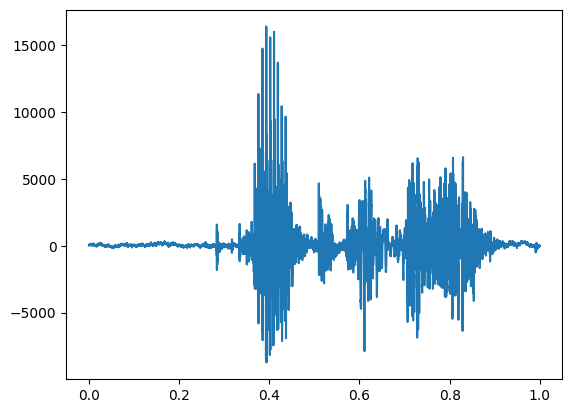

In [ ]:
filenames = tf.io.gfile.glob(str(data_dir) + '/*.wav')
#Testing if audio data imported correctly
filenames[0]
test_wav=filenames[0]
fs, test_wav = wavfile.read(test_wav)

# Ensure test_wav has a length of fs (16000 samples) for consistent plotting
if (len(test_wav) < fs):
    padding=fs-len(test_wav)
    extra_padding=np.zeros(padding).astype(np.int16) #array of empty audio to pad with
    test_wav=np.concatenate((test_wav,extra_padding),axis=0).astype(np.int16)
elif (len(test_wav) > fs):
    test_wav = test_wav[:fs].astype(np.int16)

plt.plot(np.arange(1*fs)/fs, test_wav)
plt.show()
ipd.Audio(test_wav, rate=fs)

In [ ]:
#initializing variables for 1/8th second time shifts
one_eighth=int((sample_rate/8)) #16k sample rate means 2k for 1/8s
padding=one_eighth #Number of samples to pad
#zero_padding=np.zeros(padding).astype(np.int16) #array of empty audio to pad with
noise_lvl_min=-200 #about the min for quiet room when measured with get audio code above
noise_lvl_max=200 #about the max for quiet room when measured with get audio code above
noise_padding=np.random.randint(noise_lvl_min,noise_lvl_max+1,padding) #makes random noise

**Set Augment Count**

In [ ]:
#how many of each type of time shift is desired..in 1/8s increments
#suggest following bell curve with center being zero_shift and left_3/right_3 being the extremes

left_3=1
left_2=2
left_1=2
zero_shift=2
right_1=2
right_2=2
right_3=1

total=zero_shift+right_3+right_2+right_1+left_3+left_2+left_1

In [ ]:
print("This will expand the current", len(filenames), "files by creating an addtional",len(filenames)*total, "time shifted files, to give a total of",len(filenames)*(total+1),"files")

This will expand the current 5 files by creating an addtional 60 time shifted files, to give a total of 65 files


In [ ]:
keyword_directory

NameError: name 'keyword_directory' is not defined

In [ ]:
#creates dictionary to hold audio for data visualization
audio_dict={}

##This will randomize audio samples
#random_list = list(range(0, len(filenames))) #create array [1,2,3...]
#random.shuffle(random_list) #randomize the array

#This will reverse the list so the element printed in next cell shows augmentation to original sample
random_list = list(range(0, len(filenames))) #create array [1,2,3...]
random_list.reverse() #randomize the array

#runs 5x shifts audio from original to left by .5sec in 1/8s increments
for index in range(len(filenames)):
    test_wav_path = filenames[random_list[index]]
    fs, test_wav = wavfile.read(test_wav_path)

    # Ensure test_wav has a length of fs (16000 samples)
    if (len(test_wav) < fs):
        padding=fs-len(test_wav)
        extra_padding=np.zeros(padding).astype(np.int16)
        test_wav=np.concatenate((test_wav,extra_padding),axis=0).astype(np.int16)
    elif (len(test_wav) > fs):
        test_wav = test_wav[:fs].astype(np.int16)

    audio_dict[0]=test_wav.astype(np.int16)#dict[0] holds original audio
    test_wav_decrease = test_wav #creating copy to be manipulated
    test_wav_increase = test_wav #creating copy to be manipulated

    #shift audio to left in 1/8s increments
    for j in range(1,4):#dict 1-4 hold shifted audio (change 4 to 5 to make 1/2s shift)
        for i in range (one_eighth):
            test_wav_decrease=np.delete(test_wav_decrease,0)
        test_wav_decrease=np.concatenate((test_wav_decrease,noise_padding),axis=0).astype(np.int16)
        audio_dict[j]=test_wav_decrease.astype(np.int16)
        if (j==1):
            for p in range(left_1): #creates left_1 copys shifted left 1/8s
                current_name = str(keyword_directory) + str(keyword)+f"_Sample{index}_LShift{j}_{p}.wav"
                write(current_name, fs, test_wav_decrease)
        if (j==2):
            for p in range(left_2): #creates left_2 copys shifted left 2/8s
                current_name = str(keyword_directory) + str(keyword)+f"_Sample{index}_LShift{j}_{p}.wav"
                write(current_name, fs, test_wav_decrease)
        if (j==3):
            for p in range(left_3): #creates left_3 copy shifted left 3/8s
                current_name = str(keyword_directory) + str(keyword)+f"_Sample{index}_LShift{j}_{p}.wav"
                write(current_name, fs, test_wav_decrease)


    #shift audio to right in 1/8s increments
    for k in range(6,9):
        #pad zeros to front
        test_wav_increase=np.concatenate((noise_padding,test_wav_increase),axis=0)
        #delete data past 16k samples
        for d in range(sample_rate,len(test_wav_increase)):
            test_wav_increase=np.delete(test_wav_increase,sample_rate,0).astype(np.int16)
        audio_dict[k]=test_wav_increase
        if (k==6):
            for p in range(right_1): #creates right_1 copys shifted right 1/8s
                current_name = str(keyword_directory) + str(keyword)+f"_Sample{index}_RShift{k-5}_{p}.wav"
                write(current_name, fs, test_wav_decrease)
        if (k==7):
            for p in range(right_2): #creates right_2 copys shifted right 2/8s
                current_name = str(keyword_directory) + str(keyword)+f"_Sample{index}_RShift{k-5}_{p}.wav"
                write(current_name, fs, test_wav_decrease)
        if (k==8):
            for p in range(right_3): #creates right_3 copy shifted right 3/8s
                current_name = str(keyword_directory) + str(keyword)+f"_Sample{index}_RShift{k-5}_{p}.wav"
                write(current_name, fs, test_wav_decrease)
    for l in range(zero_shift):
        current_name = str(keyword_directory) + str(keyword)+f"_Sample{index}_NoShift_{l}.wav"
        write(current_name, fs, test_wav)

**Plot time shifted audio**

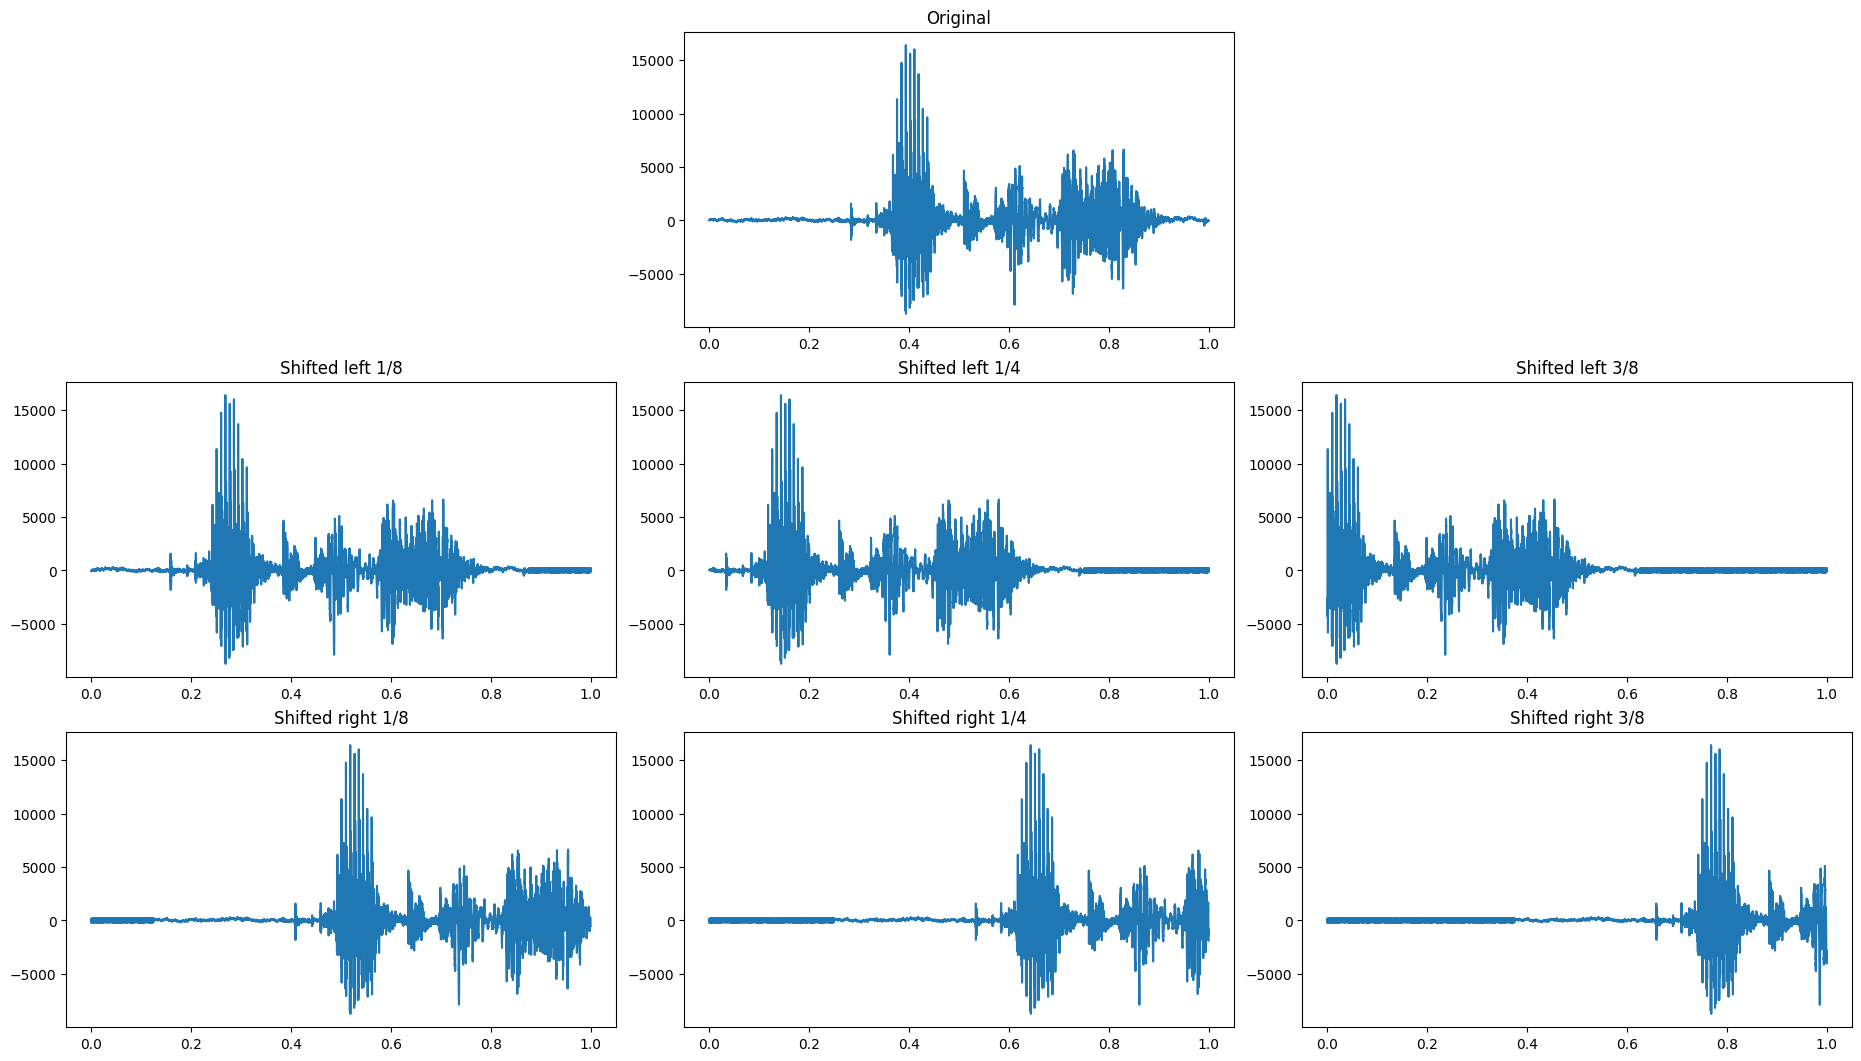

In [ ]:
#commented out is for half second shift if desired

fig = plt.figure(constrained_layout=True)
axs = fig.add_gridspec(3, 3)

f_ax0 = fig.add_subplot(axs[0, 1])
f_ax1 = fig.add_subplot(axs[1, 0])
f_ax2 = fig.add_subplot(axs[1, 1])
f_ax3 = fig.add_subplot(axs[1, 2])
# f_ax4 = fig.add_subplot(axs[2, 3])
f_ax6 = fig.add_subplot(axs[2, 0])
f_ax7 = fig.add_subplot(axs[2, 1])
f_ax8 = fig.add_subplot(axs[2, 2])
# f_ax9 = fig.add_subplot(axs[3, 3])

f_ax0.plot(np.arange(1*fs)/fs, audio_dict[0])
f_ax1.plot(np.arange(1*fs)/fs, audio_dict[1])
f_ax2.plot(np.arange(1*fs)/fs, audio_dict[2])
f_ax3.plot(np.arange(1*fs)/fs, audio_dict[3])
# f_ax4.plot(np.arange(1*fs)/fs, audio_dict[4])
f_ax6.plot(np.arange(1*fs)/fs, audio_dict[6])
f_ax7.plot(np.arange(1*fs)/fs, audio_dict[7])
f_ax8.plot(np.arange(1*fs)/fs, audio_dict[8])
# f_ax9.plot(np.arange(1*fs)/fs, audio_dict[9])

f_ax0.set_title('Original')
f_ax1.set_title('Shifted left 1/8')
f_ax2.set_title('Shifted left 1/4')
f_ax3.set_title('Shifted left 3/8')
# f_ax4.set_title('Shifted left 1/2')
f_ax6.set_title('Shifted right 1/8')
f_ax7.set_title('Shifted right 1/4')
f_ax8.set_title('Shifted right 3/8')
# f_ax9.set_title('Shifted right 1/2')
fig.set_size_inches(18.5, 10.5, forward=True)
pass

**Listen to Time Shifted Audio**

In [ ]:
from IPython.display import Audio
from IPython.display import display

print("Original:")
display(Audio(audio_dict[0], rate=fs))
print("Shifted left 1/8:")
display(Audio(audio_dict[1], rate=fs))
print("Shifted left 1/4:")
display(Audio(audio_dict[2], rate=fs))
print("Shifted left 3/8:")
display(Audio(audio_dict[3], rate=fs))
# print("Shifted left 1/2:")
# display(Audio(audio_dict[4], rate=fs))
print("Shifted right 1/8:")
display(Audio(audio_dict[6], rate=fs))
print("Shifted right 1/4:")
display(Audio(audio_dict[7], rate=fs))
print("Shifted right 3/8:")
display(Audio(audio_dict[8], rate=fs))
# print("Shifted right 1/2:")
# display(Audio(audio_dict[9], rate=fs))

Original:


Shifted left 1/8:


Shifted left 1/4:


Shifted left 3/8:


Shifted right 1/8:


Shifted right 1/4:


Shifted right 3/8:


**Pitch Shift**

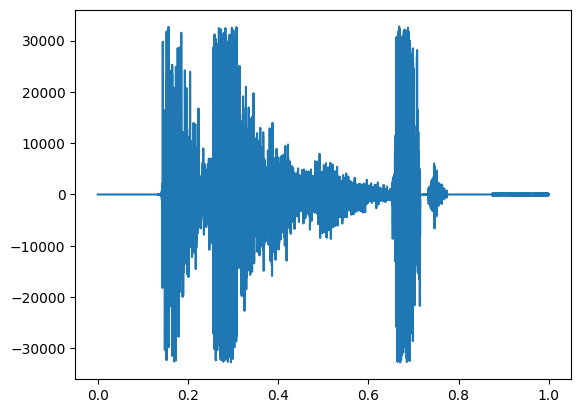

In [ ]:
#Need to update filenames
data_dir = dir
filenames = tf.io.gfile.glob(str(data_dir) + '/*.wav')
#Testing if audio data imported correctly
filenames[0]
test_wav=filenames[0]
fs, test_wav = wavfile.read(test_wav)
plt.plot(np.arange(1*fs)/fs, test_wav)
plt.show()
ipd.Audio(test_wav, rate=fs)

In [ ]:
print("The current number of files in directory is", len(filenames))

The current number of files in directory is 268


In [ ]:
import os

folder_path = '/content/drive/MyDrive/esp32_dataset/Activate/Augmented_activate'
num_files = len([name for name in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, name))])
print(f"Number of files in '{folder_path}': {num_files}")

Number of files in '/content/drive/MyDrive/esp32_dataset/Activate/Augmented_activate': 268


**GOOGLE Dataset -"No:**

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Download dataset (Google Speech Commands v0.02)
!wget -q http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz

# Step 3: Extract ONLY the "no" folder
import tarfile
import os

extract_path = "/content/speech_commands"
os.makedirs(extract_path, exist_ok=True)

with tarfile.open("speech_commands_v0.02.tar.gz", "r:gz") as tar:
    members = [m for m in tar.getmembers() if m.name.startswith("no/")]
    tar.extractall(path=extract_path, members=members)

print("Extracted 'no' folder")

# Step 4: Get all "no" files
import glob
import random
import shutil

no_files = glob.glob(os.path.join(extract_path, "no", "*.wav"))
print("Total 'no' samples available:", len(no_files))



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted 'no' folder
Total 'no' samples available: 0


/tmp/ipykernel_5272/3848815215.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path, members=members)


In [ ]:
# Step 5: Randomly pick samples
random.seed(42)
num_samples_to_pick = 268

if len(no_files) < num_samples_to_pick:
    print(f"Warning: Not enough 'no' samples available ({len(no_files)}). Picking all available samples.")
    selected_files = no_files
else:
    selected_files = random.sample(no_files, num_samples_to_pick)

# Step 6: Copy to your Drive folder
target_dir = "/content/drive/MyDrive/esp32_dataset/No"
os.makedirs(target_dir, exist_ok=True)

for file in selected_files:
    shutil.copy(file, target_dir)

print(f"Copied {len(selected_files)} 'no' samples to:", target_dir)

Copied 0 'no' samples to: /content/drive/MyDrive/esp32_dataset/No


**Data Preparation for the word - "NO" from google 30 dataset**

In [ ]:
pip install tf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
# In[2]:


# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow.keras import Input, layers
from tensorflow.keras import models
from tensorflow.lite.experimental.microfrontend.python.ops import audio_microfrontend_op as frontend_op
from tensorflow.keras.layers import Normalization
print(tf.__version__)

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import os, glob, pathlib, time, random

from datetime import datetime as dt
from IPython import display
import platform

2.20.0


In [ ]:
# In[3]:


# Set seed for experiment reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [ ]:
# In[4]:

APPLE_SILICON = platform.processor() == 'arm'
# Define range of 16-bit integers
i16min = -2**15
i16max = 2**15-1
fsamp = 16000 # sampling rate
wave_length_ms = 1000 # 1000 => 1 sec of audio
wave_length_samps = int(wave_length_ms*fsamp/1000)

# you can change these next three
window_size_ms=64
window_step_ms=48
num_filters = 32
batch_size = 32
use_microfrontend = True # recommended, but you can use another feature extractor if you like

## uncomment exactly one of these
dataset = 'mini-speech'
# dataset = 'full-speech-files' # use the full speech commands stored as files

commands = ['no'] ## Change this line for your custom keywords

# limit the instances of each command in the training set to simulate limited data
limit_positive_samples = True
max_wavs_0 = 50  # use no more than ~ samples of commands[0]
max_wavs_1 = 250  # use no more than ~ samples of commands[1]

silence_str = "_silence"  # label for <no speech detected>
unknown_str = "_unknown"  # label for <speech detected but not one of the target words>
EPOCHS = 25

print(f"FFT window length = {int(window_size_ms * fsamp / 1000)}")

might_be = {True:"IS", False:"IS NOT"} # useful for formatting conditional sentences

FFT window length = 1024


In [ ]:
# Apply the frontend to an example signal.

# In[44]:

if dataset == 'mini-speech':
  #data_dir = pathlib.Path(os.path.join(os.getenv("HOME"), 'data/mini_speech_commands'))
  data_dir = '/content/data/mini_speech_commands_extracted/mini_speech_commands'
  data_dir = pathlib.Path(data_dir)
  if not data_dir.exists():
    tf.keras.utils.get_file('mini_speech_commands.zip',
          origin="http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip",
          extract=True, cache_dir='.', cache_subdir='data'
                           )
  # commands = np.array(tf.io.gfile.listdir(str(data_dir))) # if you want to use all the command words
  # commands = commands[commands != 'README.md']
elif dataset == 'full-speech-files':
  data_dir = pathlib.Path(os.path.join(os.getenv("HOME"), 'data', 'speech_commands_v0.02'))
  if not data_dir.exists():
    raise RuntimeError("Either download the speech commands files to {data_dir} or change this code to where you have them")
else:
  raise RuntimeError('dataset should either be "mini-speech" or "full-speech-files"')

182082353/182082353 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [ ]:
# In[7]:
label_list = commands.copy() # duplicate of target words ['yes' and 'no]
label_list.insert(0, silence_str)
label_list.insert(1, unknown_str)
print('label_list:', label_list) # The Final List: ['_silence', '_unknown', 'left', 'right']


label_list: ['_silence', '_unknown', 'no']


In [ ]:
# In[8]:
if dataset in ['mini-speech', 'full-speech-files']:
    filenames = tf.io.gfile.glob(str(data_dir) + '/*/*.wav')
    #filenames = tf.io.gfile.glob(str(data_dir) + os.sep + '*' + '/' + '*.wav')
    #filenames = glob.glob(os.path.join(str(data_dir), '*', '*.wav'))

    # with the next commented-out line, you can choose only files for words in label_list
    # filenames = tf.concat([tf.io.gfile.glob(str(data_dir) + '/' + cmd + '/*') for cmd in label_list], 0)
    random.shuffle(filenames)
    num_samples = len(filenames)
    print('Number of total examples:', num_samples)
    # print('Number of examples per label:',
    #       len(tf.io.gfile.listdir(str(data_dir/commands[0]))))
    print('Example file tensor:', filenames[0])

Number of total examples: 8000
Example file tensor: /content/data/mini_speech_commands_extracted/mini_speech_commands/yes/9ff2d2f4_nohash_0.wav


In [ ]:
import os

dir_path = '/content/data/mini_speech_commands_extracted/mini_speech_commands/no'
file_count = len(os.listdir(dir_path))
print(f"The directory '{dir_path}' contains {file_count} items.")

The directory '/content/data/mini_speech_commands_extracted/mini_speech_commands/no' contains 1000 items.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

source_dir = '/content/data/mini_speech_commands_extracted/mini_speech_commands/no'
target_dir = '/content/drive/MyDrive/esp32_dataset/No'
num_files_to_copy = 300

# Ensure target directory exists
os.makedirs(target_dir, exist_ok=True)

# Get list of files in the source directory
all_files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]

# Select the first 'num_files_to_copy' files
selected_files = all_files[:num_files_to_copy]

# Copy the selected files
copied_count = 0
for filename in selected_files:
    source_path = os.path.join(source_dir, filename)
    target_path = os.path.join(target_dir, filename)
    shutil.copy(source_path, target_path)
    copied_count += 1

print(f"Successfully copied {copied_count} files from '{source_dir}' to '{target_dir}'.")

Successfully copied 300 files from '/content/data/mini_speech_commands_extracted/mini_speech_commands/no' to '/content/drive/MyDrive/esp32_dataset/No'.


**Dataset - Silence Wav Files**

In [ ]:
!wget http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz
!tar -xzf speech_commands_v0.02.tar.gz

--2026-05-03 00:10:19--  http://download.tensorflow.org/data/speech_commands_v0.02.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 172.253.118.207, 74.125.200.207, 74.125.130.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|172.253.118.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2428923189 (2.3G) [application/gzip]
Saving to: ‘speech_commands_v0.02.tar.gz’

speech_commands_v0. 100%[===================>]   2.26G  18.6MB/s    in 2m 2s   

2026-05-03 00:12:21 (19.0 MB/s) - ‘speech_commands_v0.02.tar.gz’ saved [2428923189/2428923189]



In [ ]:
import os
import random
import soundfile as sf

# Source folder (background noise = silence class)
source_dir = "./_background_noise_"

# Output directory (your Google Drive)
output_dir = "/content/drive/MyDrive/esp32_dataset/Silence"
os.makedirs(output_dir, exist_ok=True)

# Get all noise files
noise_files = [os.path.join(source_dir, f) for f in os.listdir(source_dir) if f.endswith(".wav")]

print(f"Found {len(noise_files)} background noise files")

# Function to extract random 1-second clip
def extract_1s(audio, sr=16000):
    if len(audio) <= sr:
        return audio
    start = random.randint(0, len(audio) - sr)
    return audio[start:start+sr]

count = 0

while count < 300:
    file = random.choice(noise_files)
    audio, sr = sf.read(file)

    clip = extract_1s(audio, sr)

    out_path = os.path.join(output_dir, f"silence_{count}.wav")
    sf.write(out_path, clip, sr)

    count += 1

print("✅ Done! 300 silence WAV files saved.")

Found 6 background noise files
✅ Done! 300 silence WAV files saved.


In [ ]:
import os

output_dir = "/content/drive/MyDrive/esp32_dataset/No"

removed = 0
for f in os.listdir(output_dir):
    if f.startswith("silence_") and f.endswith(".wav"):
        os.remove(os.path.join(output_dir, f))
        removed += 1

print(f"🗑️ Removed {removed} silence files.")

🗑️ Removed 300 silence files.


**Prepare data for Training, Validation & Testing**

In [ ]:
!pip install split-folders

In [ ]:
import os
import splitfolders
from pathlib import Path

# Define the source directories based on your script
ROOT_DIR = "/content/drive/MyDrive/esp32_dataset"
# Note: Your script creates 'Augmented_activate' inside the Activate folder
ACTIVATE_PATH = os.path.join(ROOT_DIR, "Activate/Augmented_activate2")
NO_PATH = os.path.join(ROOT_DIR, "No")
SILENCE_PATH = os.path.join(ROOT_DIR, "Silence")

# Create a temporary unified directory for splitting
!mkdir -p /content/temp_dataset/activate
!mkdir -p /content/temp_dataset/no
!mkdir -p /content/temp_dataset/silence

# Sync files to temp directory for organization
!cp -r "{ACTIVATE_PATH}"/* /content/temp_dataset/activate/
!cp -r "{NO_PATH}"/* /content/temp_dataset/no/
!cp -r "{SILENCE_PATH}"/* /content/temp_dataset/silence/

# Split into Train (80%), Val (10%), Test (10%)
splitfolders.ratio("/content/temp_dataset", output="/content/final_split",
                   seed=42, ratio=(.8, .1, .1))

Copying files: 928 files [00:00, 6380.01 files/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Loading function for 16kHz WAVs
def load_audio(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(contents=audio_binary)
    waveform = tf.squeeze(audio, axis=-1)
    # Ensure exactly 16000 samples (1 second)
    waveform = waveform[:16000]
    padding = tf.zeros([16000] - tf.shape(waveform), dtype=tf.float32)
    return tf.concat([waveform, padding], 0)

# 2. Spectrogram conversion
def get_spectrogram(waveform):
    # STFT parameters tuned for microcontrollers
    spectrogram = tf.signal.stft(waveform, frame_length=255, frame_step=128)
    spectrogram = tf.abs(spectrogram)
    return spectrogram[..., tf.newaxis] # Add channel dimension

def prepare_ds(path):
    files = tf.io.gfile.glob(path + '/*/*.wav')
    # Labeling: activate=0, no=1, silence=2
    labels = [0 if 'activate' in f else 1 if 'no' in f else 2 for f in files]

    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    ds = ds.map(lambda f, l: (get_spectrogram(load_audio(f)), l))
    return ds.batch(32).cache().prefetch(tf.data.AUTOTUNE)

train_ds = prepare_ds("/content/final_split/train")
val_ds = prepare_ds("/content/final_split/val")
test_ds = prepare_ds("/content/final_split/test")

# 3. Lightweight CNN Architecture
model = models.Sequential([
    layers.Input(shape=(124, 129, 1)), # Default STFT shape for 16kHz
    layers.Resizing(32, 32),           # Shrink for ESP32 memory efficiency
    layers.Normalization(),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax') # Activate, No, Silence
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=22,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

# Test the model
print("\n--- Evaluation on Unseen Test Data ---")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

Epoch 1/22
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.2830 - loss: 3.2072 - val_accuracy: 0.3478 - val_loss: 1.0522
Epoch 2/22
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3854 - loss: 1.0627 - val_accuracy: 0.3478 - val_loss: 1.0255
Epoch 3/22
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3571 - loss: 1.0785 - val_accuracy: 0.3478 - val_loss: 0.9496
Epoch 4/22
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3760 - loss: 0.9568 - val_accuracy: 0.4674 - val_loss: 0.8525
Epoch 5/22
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5458 - loss: 0.8132 - val_accuracy: 0.7065 - val_loss: 0.7212
Epoch 6/22
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7022 - loss: 0.6720 - val_accuracy: 0.8152 - val_loss: 0.5793
Epoch 7/22
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7722 - loss: 0.5693 - val_accuracy: 0.8587 - val_loss: 0.4822
Epoch 8/22
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8585 - loss: 0.4699 - val_accuracy: 0.8804 - val_los

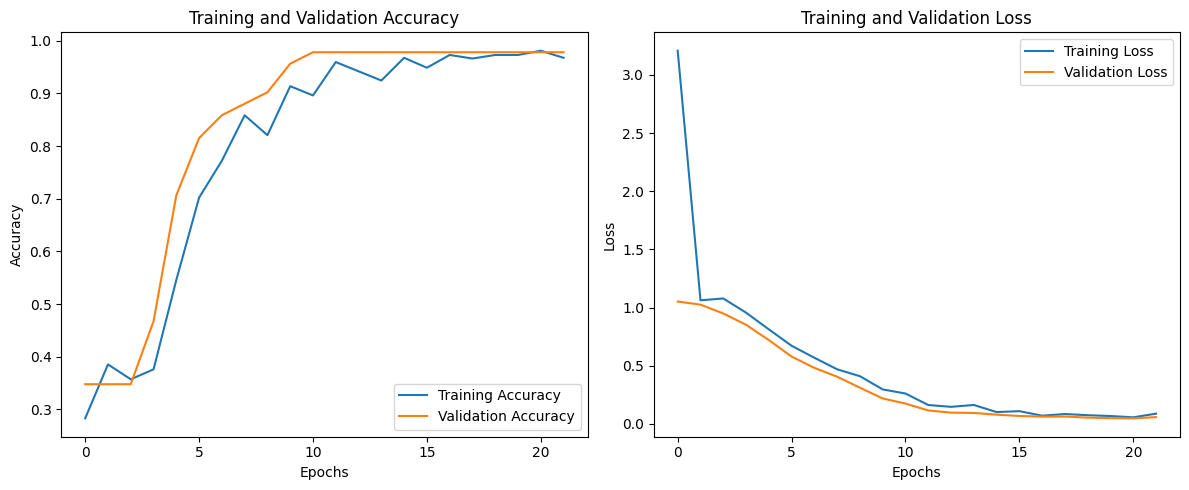

In [ ]:
import matplotlib.pyplot as plt

# Retrieve accuracy and loss from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step

✅ Final Test Accuracy: 95.74%


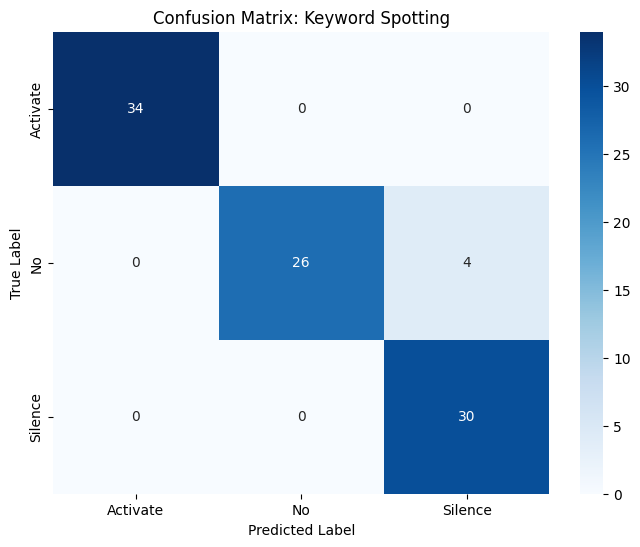


Detailed Classification Report:
              precision    recall  f1-score   support

    Activate       1.00      1.00      1.00        34
          No       1.00      0.87      0.93        30
     Silence       0.88      1.00      0.94        30

    accuracy                           0.96        94
   macro avg       0.96      0.96      0.96        94
weighted avg       0.96      0.96      0.96        94



In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions for the entire test set
y_true = []
y_pred = []

for audio, label in test_ds:
    prediction = model.predict(audio)
    y_pred.extend(np.argmax(prediction, axis=1))
    y_true.extend(label.numpy())

# 2. Calculate Testing Accuracy
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n✅ Final Test Accuracy: {test_acc*100:.2f}%")

# 3. Generate Confusion Matrix
# Labels should match the order: 0: Activate, 1: No, 2: Silence
class_names = ['Activate', 'No', 'Silence']
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Keyword Spotting')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Detailed Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix

def get_layer_stats(model):
    """Robustly estimate MACs and Params for reporting."""
    total_macs = 0
    total_params = model.count_params()

    for layer in model.layers:
        # Check for Convolutional layers
        if isinstance(layer, tf.keras.layers.Conv2D):
            weights = layer.get_weights()
            if not weights: continue

            # Kernel: [h, w, in_c, out_c]
            k_h, k_w, in_c, out_c = weights[0].shape

            # Get output spatial dimensions [batch, h, w, c]
            # We use .shape[1] and .shape[2] for height and width
            out_h = layer.output.shape[1]
            out_w = layer.output.shape[2]

            # MACs = (Kern_H * Kern_W * In_C) * (Out_H * Out_W * Out_C)
            layer_macs = (k_h * k_w * in_c) * (out_h * out_w * out_c)
            total_macs += layer_macs

        # Check for Dense layers
        elif isinstance(layer, tf.keras.layers.Dense):
            weights = layer.get_weights()
            if not weights: continue
            # MACs = inputs * outputs
            total_macs += weights[0].shape[0] * weights[0].shape[1]

    return int(total_macs), total_params

# 1. Evaluate Dataset Accuracy (Software Accuracy)
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

# 2. Collect Predictions for FRR
y_true, y_pred = [], []
for audio, label in test_ds:
    preds = model.predict(audio, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(label.numpy())

cm = confusion_matrix(y_true, y_pred)

# Mapping: 0=Activate, 1=No, 2=Silence
# FRR = (False Negatives) / (Total Actual Positives)
# A False Negative for 'Activate' is when the word was said (0) but predicted as No (1) or Silence (2)
frr_activate = (cm[0, 1] + cm[0, 2]) / np.sum(cm[0, :]) if np.sum(cm[0, :]) > 0 else 0
frr_no = (cm[1, 0] + cm[1, 2]) / np.sum(cm[1, :]) if np.sum(cm[1, :]) > 0 else 0

# 3. Calculate Hardware Metrics
macs, params = get_layer_stats(model)

print("\n" + "="*45)
print("       DEEP LEARNING MODEL SUMMARY REPORT")
print("="*45)
print(f"{'Training Accuracy:':<30} {train_acc*100:>8.2f}%")
print(f"{'Validation Accuracy:':<30} {val_acc*100:>8.2f}%")
print(f"{'Testing Accuracy:':<30} {test_acc*100:>8.2f}%")
print("-" * 45)
print(f"{'FRR (Custom: Activate):':<30} {frr_activate:>8.4f}")
print(f"{'FRR (Dataset: No):':<30} {frr_no:>8.4f}")
print("-" * 45)
print(f"{'Number of Parameters:':<30} {params:>8,}")
print(f"{'Estimated MACs:':<30} {macs:>8,}")
print(f"{'Input Tensor Shape:':<30} {str(model.input_shape):>8}")
print(f"{'Sampling Rate (Audio):':<30} {'16,000 Hz':>8}")
print("="*45)


       DEEP LEARNING MODEL SUMMARY REPORT
Training Accuracy:                98.38%
Validation Accuracy:              97.83%
Testing Accuracy:                 95.74%
---------------------------------------------
FRR (Custom: Activate):          0.0000
FRR (Dataset: No):               0.1333
---------------------------------------------
Number of Parameters:           166,534
Estimated MACs:                3,521,856
Input Tensor Shape:            (None, 124, 129, 1)
Sampling Rate (Audio):         16,000 Hz


In [ ]:
!pip install tf-keras

In [ ]:
import tensorflow as tf
import tf_keras as keras
import tensorflow_model_optimization as tfmot

# 1. Define a "Clean" model without the Resizing layer
def build_qat_compatible_model():
    # We change the input shape to (32, 32, 1) directly
    # This means we must resize the spectrograms in the dataset, not the model
    model = keras.Sequential([
        keras.layers.Input(shape=(32, 32, 1)),
        keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
        keras.layers.MaxPooling2D(),
        keras.layers.Dropout(0.25),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(3, activation='softmax')
    ])
    return model

# 2. Update your Dataset to handle resizing
# This ensures the model receives the (32, 32) shape it expects
def resize_ds(ds):
    return ds.map(lambda x, y: (tf.image.resize(x, (32, 32)), y))

train_ds_resized = resize_ds(train_ds)
val_ds_resized = resize_ds(val_ds)
test_ds_resized = resize_ds(test_ds)

# 3. Wrap for Quantization Aware Training
base_model = build_qat_compatible_model()
quantize_model = tfmot.quantization.keras.quantize_model
q_aware_model = quantize_model(base_model)

q_aware_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("✅ SUCCESS: Model is now QAT compatible!")

✅ SUCCESS: Model is now QAT compatible!


In [ ]:
import tf_keras as keras

# 1. Create the callback using the correct legacy library
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 2. Run the fine-tuning
history_qat = q_aware_model.fit(
    train_ds_resized,
    validation_data=val_ds_resized,
    epochs=10,
    callbacks=[early_stopping] # Now compatible
)

# 3. Final Accuracy Check
print("\n--- Final Evaluation of Quantization Aware Model ---")
q_test_loss, q_test_acc = q_aware_model.evaluate(test_ds_resized)
print(f"QAT Model Accuracy: {q_test_acc*100:.2f}%")

Epoch 1/10
24/24 [==============================] - 4s 25ms/step - loss: 4.7747 - accuracy: 0.3356 - val_loss: 1.2539 - val_accuracy: 0.3587
Epoch 2/10
24/24 [==============================] - 0s 9ms/step - loss: 1.0022 - accuracy: 0.3801 - val_loss: 0.8513 - val_accuracy: 0.5652
Epoch 3/10
24/24 [==============================] - 0s 8ms/step - loss: 0.8056 - accuracy: 0.5121 - val_loss: 0.6461 - val_accuracy: 0.6630
Epoch 4/10
24/24 [==============================] - 0s 8ms/step - loss: 0.7227 - accuracy: 0.6887 - val_loss: 0.4711 - val_accuracy: 0.8261
Epoch 5/10
24/24 [==============================] - 0s 8ms/step - loss: 0.4760 - accuracy: 0.8261 - val_loss: 0.4121 - val_accuracy: 0.8370
Epoch 6/10
24/24 [==============================] - 0s 8ms/step - loss: 0.4041 - accuracy: 0.8518 - val_loss: 0.2978 - val_accuracy: 0.9348
Epoch 7/10
24/24 [==============================] - 0s 8ms/step - loss: 0.2733 - accuracy: 0.9286 - val_loss: 0.2378 - val_accuracy: 0.9348
Epoch 8/10
24/24 [=

In [ ]:
import tensorflow as tf

# Convert the Q-Aware model
converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Crucial for ESP32-S3 hardware acceleration
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_qat_model = converter.convert()

# Save the binary file
with open("model_final_qat.tflite", "wb") as f:
    f.write(tflite_qat_model)

# Generate C++ Hex dump for Arduino/ESP-IDF
!xxd -i model_final_qat.tflite > model_data.cc
print("✅ model_data.cc created. Copy the array into your ESP32 project.")

✅ model_data.cc created. Copy the array into your ESP32 project.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Running inference on quantized model...


<Figure size 800x600 with 0 Axes>

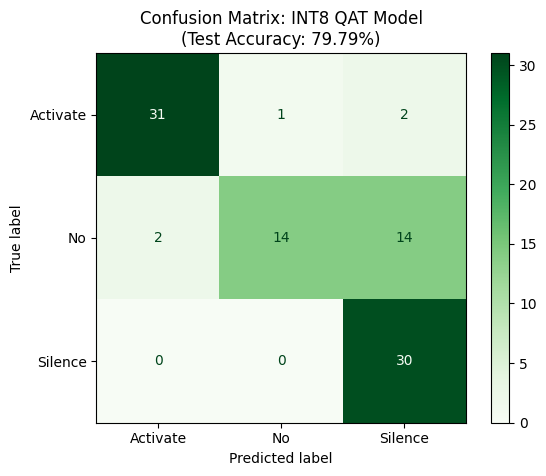

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_qat_tflite(model_path, dataset):
    # 1. Load the TFLite model and allocate tensors
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # Get quantization parameters to convert float inputs to int8
    input_scale, input_zero_point = input_details['quantization']

    y_true = []
    y_pred = []

    print("Running inference on quantized model...")
    for images, labels in dataset:
        for i in range(len(images)):
            # Pre-process: Scale float to int8
            input_data = images[i].numpy()
            input_data = (input_data / input_scale) + input_zero_point
            input_data = np.expand_dims(input_data.astype(np.int8), axis=0)

            # Run inference
            interpreter.set_tensor(input_details['index'], input_data)
            interpreter.invoke()

            # Get output and de-quantize/argmax
            output_data = interpreter.get_tensor(output_details['index'])
            y_pred.append(np.argmax(output_data))
            y_true.append(labels[i].numpy())

    return np.array(y_true), np.array(y_pred)

# 1. Execute inference
y_true, y_pred = evaluate_qat_tflite("model_final_qat.tflite", test_ds_resized)

# 2. Define labels based on your training
class_names = ['Activate', 'No', 'Silence']

# 3. Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Greens, values_format='d')
plt.title(f'Confusion Matrix: INT8 QAT Model\n(Test Accuracy: {np.mean(y_true==y_pred)*100:.2f}%)')
plt.show()

In [ ]:
# Calculate weights (or set manually to favor the struggling 'No' class)
# Assuming: 0: Activate, 1: No, 2: Silence
class_weight = {0: 1.0, 1: 2.5, 2: 1.0}

# Re-run fine-tuning with weights
history_qat = q_aware_model.fit(
    train_ds_resized,
    validation_data=val_ds_resized,
    epochs=15, # Increased slightly
    class_weight=class_weight,
    callbacks=[early_stopping]
)

Epoch 1/15
24/24 [==============================] - 1s 10ms/step - loss: 0.2319 - accuracy: 0.9461 - val_loss: 0.1332 - val_accuracy: 0.9783
Epoch 2/15
24/24 [==============================] - 0s 9ms/step - loss: 0.2183 - accuracy: 0.9555 - val_loss: 0.1137 - val_accuracy: 0.9783
Epoch 3/15
24/24 [==============================] - 0s 9ms/step - loss: 0.1993 - accuracy: 0.9569 - val_loss: 0.0888 - val_accuracy: 0.9783
Epoch 4/15
24/24 [==============================] - 0s 9ms/step - loss: 0.1437 - accuracy: 0.9704 - val_loss: 0.0778 - val_accuracy: 0.9783
Epoch 5/15
24/24 [==============================] - 0s 8ms/step - loss: 0.1438 - accuracy: 0.9488 - val_loss: 0.0940 - val_accuracy: 0.9783
Epoch 6/15
24/24 [==============================] - 0s 9ms/step - loss: 0.0841 - accuracy: 0.9865 - val_loss: 0.0703 - val_accuracy: 0.9783
Epoch 7/15
24/24 [==============================] - 0s 8ms/step - loss: 0.1342 - accuracy: 0.9407 - val_loss: 0.0846 - val_accuracy: 0.9783
Epoch 8/15
24/24 [=

In [ ]:
# Amplify the waveform slightly to use more of the INT8 dynamic range
audio = audio * 1.5
# Then proceed to spectrogram generation

In [ ]:
!pip install --upgrade tensorflow-model-optimization

In [ ]:
import tensorflow as tf
import tf_keras as keras # The legacy backend
import tensorflow_model_optimization as tfmot

# 1. Define the optimizer using the legacy backend
# This avoids the "Could not interpret optimizer identifier" error
legacy_optimizer = keras.optimizers.Adam(learning_rate=1e-4)

# 2. Selective Quantization (Excluding the final layer to preserve "No" accuracy)
def apply_selective_quant(layer):
    # Only quantize Conv2D and the first Dense layer
    if isinstance(layer, keras.layers.Conv2D):
        return tfmot.quantization.keras.quantize_annotate_layer(layer)
    if isinstance(layer, keras.layers.Dense) and layer.name != 'dense_1':
        return tfmot.quantization.keras.quantize_annotate_layer(layer)
    return layer

# 3. Re-build and Apply
annotated_model = keras.models.clone_model(
    base_model,
    clone_function=apply_selective_quant,
)
q_aware_model = tfmot.quantization.keras.quantize_apply(annotated_model)

# 4. Compile using the LEGACY optimizer
q_aware_model.compile(
    optimizer=legacy_optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Aggressive Class Weights to fix the 79% accuracy
# We give 'No' (index 1) 3x the importance to stop it from being called 'Silence'
class_weights = {0: 1.0, 1: 3.0, 2: 1.0}

print("✅ Model compiled with Legacy Optimizer. Starting fine-tuning...")

q_aware_model.fit(
    train_ds_resized,
    validation_data=val_ds_resized,
    epochs=15, # Extra epochs to help the 'No' class stabilize
    class_weight=class_weights
)

✅ Model compiled with Legacy Optimizer. Starting fine-tuning...
Epoch 1/15
24/24 [==============================] - 2s 17ms/step - loss: 2.4666 - accuracy: 0.2911 - val_loss: 1.0198 - val_accuracy: 0.4348
Epoch 2/15
24/24 [==============================] - 0s 8ms/step - loss: 1.4865 - accuracy: 0.5714 - val_loss: 0.7690 - val_accuracy: 0.7826
Epoch 3/15
24/24 [==============================] - 0s 8ms/step - loss: 1.3377 - accuracy: 0.7466 - val_loss: 0.6413 - val_accuracy: 0.7717
Epoch 4/15
24/24 [==============================] - 0s 8ms/step - loss: 1.1329 - accuracy: 0.7803 - val_loss: 0.5649 - val_accuracy: 0.7826
Epoch 5/15
24/24 [==============================] - 0s 8ms/step - loss: 0.9791 - accuracy: 0.8019 - val_loss: 0.5144 - val_accuracy: 0.7935
Epoch 6/15
24/24 [==============================] - 0s 8ms/step - loss: 0.8750 - accuracy: 0.8046 - val_loss: 0.4749 - val_accuracy: 0.8043
Epoch 7/15
24/24 [==============================] - 0s 8ms/step - loss: 0.7924 - accuracy: 0.82

<Figure size 800x600 with 0 Axes>

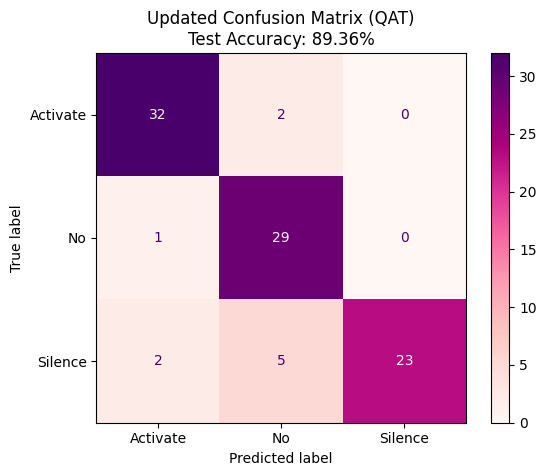

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def check_current_performance(model_to_test, dataset):
    y_true = []
    y_pred = []

    # Get predictions from the Q-Aware model
    for images, labels in dataset:
        preds = model_to_test.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    return np.array(y_true), np.array(y_pred)

# 1. Get predictions for the test set
y_true, y_pred = check_current_performance(q_aware_model, test_ds_resized)

# 2. Plot the Matrix
class_names = ['Activate', 'No', 'Silence']
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.RdPu, values_format='d') # Using a different color to distinguish from the old one
plt.title(f'Updated Confusion Matrix (QAT)\nTest Accuracy: {np.mean(y_true==y_pred)*100:.2f}%')
plt.show()

In [ ]:
q_aware_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer_3 (Quantize  (None, 32, 32, 1)         3         
 Layer)                                                          
                                                                 
 quant_conv2d_2 (QuantizeWr  (None, 32, 32, 32)        387       
 apperV2)                                                        
                                                                 
 quant_max_pooling2d_2 (Qua  (None, 16, 16, 32)        1         
 ntizeWrapperV2)                                                 
                                                                 
 quant_conv2d_3 (QuantizeWr  (None, 16, 16, 64)        18627     
 apperV2)                                                        
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 8, 8, 64)         

In [ ]:
import tensorflow as tf

# 1. Convert to INT8 TFLite again to be safe
converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

def representative_data_gen():
    for input_value, _ in train_ds_resized.take(100):
        yield [input_value]

converter.representative_dataset = representative_data_gen
tflite_model = converter.convert()

# 2. Save the binary
with open("model_data.tflite", "wb") as f:
    f.write(tflite_model)

# 3. Generate the .cc file
!xxd -i model_data.tflite > model_data.cc

# 4. Create a clean .h file for your project
with open("model_data.h", "w") as f:
    f.write('#ifndef MODEL_DATA_H_\n')
    f.write('#define MODEL_DATA_H_\n\n')
    f.write('extern const unsigned char model_data_tflite[];\n')
    f.write('extern const int model_data_tflite_len;\n\n')
    f.write('#endif  // MODEL_DATA_H_')

print("✅ Created model_data.cc (The data)")
print("✅ Created model_data.h (The reference)")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Created model_data.cc (The data)
✅ Created model_data.h (The reference)


In [ ]:
import numpy as np
import tensorflow as tf

# 1. Load the specific TFLite file you used to create the .cc
interpreter = tf.lite.Interpreter(model_path="/content/model_data.tflite")
interpreter.allocate_tensors()

# 2. Get the input/output details
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# 3. Check if it's REALLY quantized (INT8)
if input_details['dtype'] == np.int8:
    print("✅ Confirmed: The .cc file is using 8-bit Integer weights.")
else:
    print("❌ Warning: This file is still using Floating Point!")

# 4. Final Accuracy Check on the test set
# (Run your 'evaluate_qat_tflite' function from earlier on this specific file)

✅ Confirmed: The .cc file is using 8-bit Integer weights.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
